<a href="https://colab.research.google.com/github/PratikshitSingh/AI-Model-Evaluation---Training/blob/main/AI_Model_Evaluation_MethodologyExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧩 Evaluating AI Model Performance: Customer Support Classification Example

### 🎯 Goal
This Colab demonstrates how to **evaluate AI model outputs** using a realistic customer-support classification use case.
You’ll:
1. Define success criteria (what counts as a good model?)
2. Create a **ground-truth dataset** of labeled support messages
3. Use a **zero-shot classification model** to generate predictions
4. Compute metrics such as **accuracy**, **precision**, **recall**, and **F1**
5. Visualize results using a **confusion matrix** and bar charts


In [ ]:
!pip install transformers evaluate scikit-learn matplotlib pandas --quiet
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline
import evaluate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Step 1: Create a small labeled dataset

In [ ]:
data = [
    ("I was charged twice this month", "billing_issue"),
    ("My password reset link isn’t working", "account_access"),
    ("The app crashes whenever I open reports", "technical_bug"),
    ("How do I cancel my premium plan?", "subscription_question"),
    ("Billing page won’t load properly", "billing_issue"),
    ("I can’t log into my account today", "account_access"),
    ("Getting an error code 502 on dashboard", "technical_bug"),
    ("Need to update my subscription plan", "subscription_question"),
    ("Charged after cancelling my plan", "billing_issue"),
    ("Login page says invalid credentials", "account_access")
]

dataset = pd.DataFrame(data, columns=['text', 'label'])
dataset

,text,label
0,I was charged twice this month,billing_issue
1,My password reset link isn’t working,account_access
2,The app crashes whenever I open reports,technical_bug
3,How do I cancel my premium plan?,subscription_question
4,Billing page won’t load properly,billing_issue
5,I can’t log into my account today,account_access
6,Getting an error code 502 on dashboard,technical_bug
7,Need to update my subscription plan,subscription_question
8,Charged after cancelling my plan,billing_issue
9,Login page says invalid credentials,account_access


## Step 2: Run a pre-trained zero-shot classifier

We clearly see some mismatches in the predicted column below as well... for example Login page says invalid credentials gets a predicted label of technical_bug instead of account_access (which is what it really is):

In [ ]:
# Create a zero-shot classification pipeline using a pretrained NLI model
# This allows us to classify text without any task-specific training data

# Zero-shot classification is a way to classify text into categories the model has never been explicitly trained on for your task.

# Instead of training a model on labeled examples (like “this text = billing_issue”), you:

# 👉 Give the model the labels at runtime
# 👉 It uses its general language understanding to decide which label fits best


# 🧠 Core Idea (Simple Mental Model)

# Think of it like this:

# “Given this text… which of these labels best describes it?”

# No training. No fine-tuning. Just reasoning.

classifier = pipeline('zero-shot-classification', model='facebook/bart-large-mnli')

# Define the set of candidate labels the model will choose from
# These labels act like hypotheses that the model scores against each input text
candidate_labels = ['billing_issue', 'account_access', 'technical_bug', 'subscription_question']

# Prepare a list to store the model's predicted label for each input text
predictions = []

# Iterate over each text example in the dataset
for text in dataset['text']:
    # Run zero-shot classification:
    # the model scores how well each candidate label matches the input text
    result = classifier(text, candidate_labels)

    # Select the highest-scoring label (ranked first)
    predictions.append(result['labels'][0])

# Add the model’s predictions as a new column in the dataset
dataset['predicted'] = predictions

# Display the dataset with original text and predicted labels
dataset


NameError: name 'pipeline' is not defined

## Step 3: Compute evaluation metrics

In the code below we measure 4 different metrics, lets go over each of them...

---

# Classification Metrics: Accuracy, Precision, Recall, and F1

When evaluating classification models (including zero-shot classifiers and RAG routing logic), **metrics tell you *how* the model is failing—not just whether it’s failing**.

This handout explains:

* what each metric measures
* what “good” values usually look like
* how these metrics are used in real systems

---

## 1. Accuracy

### What it is

Accuracy measures how often the model is correct overall.

Accuracy = correct_predictions / total_predictions

### Intuition

“Out of everything the model predicted, how often was it right?”

### Typical ranges

* 0.90+ → Very strong *if* classes are balanced
* 0.70–0.85 → Common in real-world NLP tasks
* < 0.60 → Often a sign of ambiguity or weak labels

### Key limitation

Accuracy hides failure modes when classes are imbalanced.

Example:

* 95% of tickets are billing_issue
* Model always predicts billing_issue
* Accuracy = 95%
* Model is useless

### When accuracy is useful

* Balanced datasets
* Sanity checks
* Early baselines

---

## 2. Precision

### What it is

Precision measures how often the model is correct *when it predicts a specific class*.

Precision = true_positives / predicted_positives

### Intuition

“When the model says X, how often is it actually X?”

### Typical ranges

* 0.85–0.95 → Strong precision
* 0.70–0.85 → Acceptable for many NLP systems
* < 0.70 → Many false positives

### When precision matters most

* Auto-routing systems
* Compliance flags
* Expensive downstream actions

Example:
If a model labels something as account_access, precision tells you how often that label is correct — important if it triggers security workflows.

---

## 3. Recall

### What it is

Recall measures how many of the *actual* relevant items the model successfully finds.

Recall = true_positives / actual_positives

### Intuition

“Of everything that should have been labeled X, how much did we catch?”

### Typical ranges

* 0.85–0.95 → Strong recall
* 0.70–0.85 → Common tradeoff range
* < 0.70 → Many misses

### When recall matters most

* Safety systems
* Search and retrieval
* Monitoring and alerting

Example:
In RAG retrieval, low recall means the correct document never reaches the LLM — no prompt can fix that.

---

## 4. F1 Score

### What it is

F1 combines precision and recall into a single score.

F1 = 2 * (precision * recall) / (precision + recall)

### Intuition

“How well does the model balance correctness and coverage?”

### Typical ranges

* 0.80+ → Strong, production-ready signal
* 0.65–0.80 → Usable with known limitations
* < 0.65 → Likely inconsistent behavior

### Why teams use F1

* Penalizes lopsided models
* Single number for comparisons
* Useful when neither precision nor recall alone is enough

---

## Macro vs Micro Averaging (Why This Matters)

### Macro averaging

* Compute metric per class
* Average equally across classes
* Exposes weak or rare categories

Best for:

* Multi-class NLP
* Fairness analysis
* Debugging failure modes

### Micro averaging

* Aggregate all predictions globally
* Dominated by frequent classes

Best for:

* High-volume systems
* Throughput-focused evaluation

---

## How These Metrics Are Used in Real Systems

### Model gating

* “Deploy only if macro F1 >= 0.78”
* Prevents regressions hidden by accuracy

### Routing logic

* High precision → auto-route
* Lower precision → human review

### Drift monitoring

* Recall usually drops first when data changes
* Precision drops when label boundaries blur

### A/B testing

* Compare per-class F1, not just accuracy
* Especially important for edge cases

---

## Key Takeaways

* Accuracy alone is not enough
* Precision controls false positives
* Recall controls false negatives
* F1 balances both and is often the best single metric
* Macro averages expose hidden failures
* Metrics should reflect real downstream cost

---


In [ ]:
# ✅ Step 3: Compute evaluation metrics properly
# ----------------------------------------------
# In this step, we measure how well our model's predictions
# match the ground-truth labels using standard classification metrics.

import evaluate

# -------------------------------------------------------------------
# What is the `evaluate` library?
# -------------------------------------------------------------------
# `evaluate` is Hugging Face’s unified evaluation framework.
# It provides:
#   - Standardized implementations of common ML metrics
#   - Consistent, reproducible metric computation
#   - Dataset- and model-agnostic APIs
#
# Unlike ad-hoc metric code, `evaluate` ensures:
#   - Correct handling of edge cases (e.g., missing labels)
#   - Consistent averaging strategies (macro, micro, weighted)
#   - Comparable results across experiments and teams
#
# Most metrics in `evaluate` expect labels to be encoded as integers,
# not strings—hence the encoding step below.

# -------------------------------------------------------------------
# 1️⃣ Encode string labels as integers
# -------------------------------------------------------------------
# Our dataset labels are strings (e.g., "billing_issue"),
# but evaluation metrics operate on numeric class IDs.
#
# We build a shared label vocabulary from:
#   - Ground-truth labels
#   - Model-predicted labels
#
# This ensures:
#   - A consistent mapping
#   - No accidental dropping of predicted-only classes
unique_labels = sorted(
    list(set(dataset["label"].tolist() + dataset["predicted"].tolist()))
)

# Create a deterministic mapping: label → integer ID
label_to_id = {label: i for i, label in enumerate(unique_labels)}

# Convert ground-truth labels into integer IDs
references = [
    label_to_id[label] for label in dataset["label"].tolist()
]

# Convert model predictions into integer IDs
predictions = [
    label_to_id[label] for label in dataset["predicted"].tolist()
]

# -------------------------------------------------------------------
# 2️⃣ Load evaluation metrics
# -------------------------------------------------------------------
# Each call to `evaluate.load()` returns a metric object
# with a standardized `.compute()` interface.
#
# Metrics used:
#   - Accuracy: overall correctness
#   - Precision: how often predicted labels are correct
#   - Recall: how often true labels are recovered
#   - F1: harmonic mean of precision and recall
accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

# -------------------------------------------------------------------
# 3️⃣ Compute metric values
# -------------------------------------------------------------------
# We use `average="macro"` for multi-class classification.
#
# Macro averaging:
#   - Computes the metric independently for each class
#   - Treats all classes equally (no class imbalance weighting)
#
# This is especially important when:
#   - Some categories are rare
#   - You care about per-class performance, not just volume
results = {
    "accuracy": accuracy.compute(
        references=references,
        predictions=predictions
    ),
    "precision": precision.compute(
        references=references,
        predictions=predictions,
        average="macro"
    ),
    "recall": recall.compute(
        references=references,
        predictions=predictions,
        average="macro"
    ),
    "f1": f1.compute(
        references=references,
        predictions=predictions,
        average="macro"
    ),
}

# -------------------------------------------------------------------
# 4️⃣ Display results
# -------------------------------------------------------------------
# Printing the label map is critical for interpretability:
# it allows you to trace metric scores back to semantic labels.
print("🔢 Label Map:", label_to_id)

# Final evaluation summary
print("✅ Evaluation Results:", results)


🔢 Label Map: {'account_access': 0, 'billing_issue': 1, 'subscription_question': 2, 'technical_bug': 3}
✅ Evaluation Results: {'accuracy': {'accuracy': 0.7}, 'precision': {'precision': 0.8125}, 'recall': {'recall': 0.7083333333333333}, 'f1': {'f1': 0.6726190476190476}}


## Step 4: Visualize confusion matrix and per-class accuracy

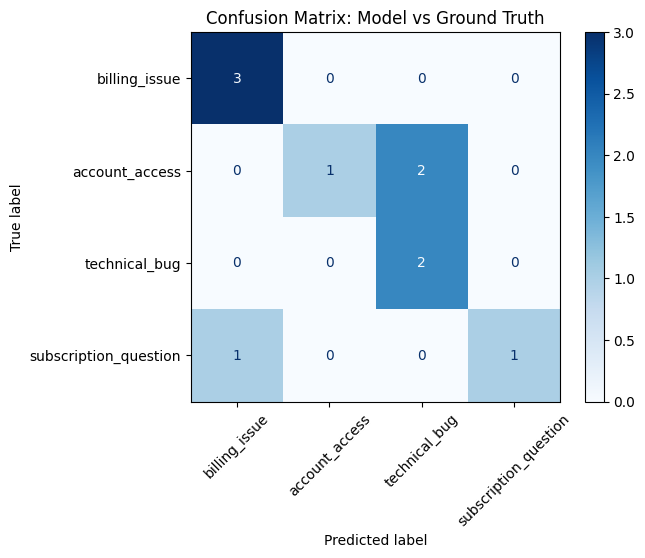

/tmp/ipykernel_1444/2306226250.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  class_acc = dataset.groupby('label').apply(lambda x: (x['label'] == x['predicted']).mean())


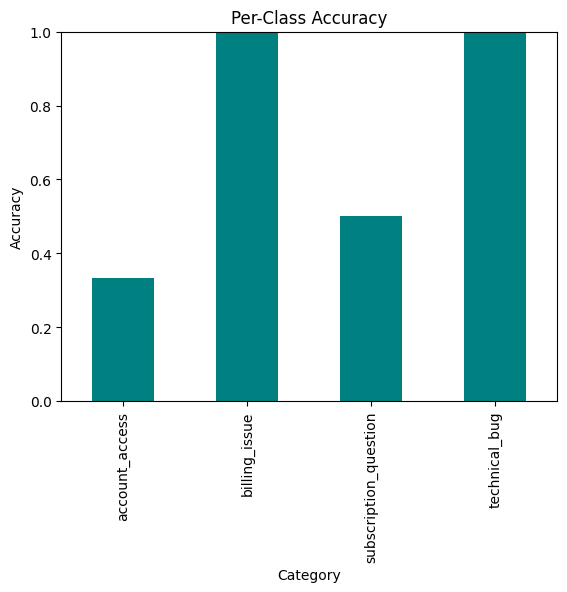

In [ ]:
cm = confusion_matrix(dataset['label'], dataset['predicted'], labels=candidate_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=candidate_labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix: Model vs Ground Truth')
plt.show()

class_acc = dataset.groupby('label').apply(lambda x: (x['label'] == x['predicted']).mean())
class_acc.plot(kind='bar', color='teal', ylim=(0,1))
plt.title('Per-Class Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Category')
plt.show()

# 🧩 Understanding the Confusion Matrix

The main thing to understand is that anything not on the diagonal going from top left to bottom right, AND that is non-zero indicates an error!


## What You’re Looking At

A **confusion matrix** is a table that compares:

* **Rows** → the *true (ground-truth) labels*
* **Columns** → the *model’s predicted labels*

Each cell shows **how many examples** fell into that true/predicted combination.

> Think of it as a *map of the model’s mistakes*, not just a scorecard.

---

## How to Read This Matrix

### Axes

* **Y-axis (rows):** what the data *actually is*
* **X-axis (columns):** what the model *predicted*

### Diagonal cells (top-left → bottom-right)

* These are **correct predictions**
* Darker = more correct examples

### Off-diagonal cells

* These are **errors**
* They show *which labels the model confuses*

---

## Walking Through This Example

### ✅ billing_issue

* 3 correct predictions
* No confusion with other categories
* **Very strong performance**

---

### ⚠️ account_access

* Only 1 correct prediction
* 2 cases misclassified as `technical_bug`

**Interpretation:**
The model struggles to distinguish:

* “I can’t log in”
  vs
* “Something is broken”

This is a *semantic overlap problem*, not random noise.

---

### ✅ technical_bug

* 2 correct predictions
* No misclassifications
* **Clean separation in this dataset**

---

### ⚠️ subscription_question

* 1 correct prediction
* 1 misclassified as `billing_issue`

**Interpretation:**
The model confuses:

* Pricing / billing
* Subscription status

This is a very common real-world failure mode.

---

## Why a Confusion Matrix Is So Useful

### 1️⃣ Metrics Don’t Tell You *Why* the Model Fails

Accuracy, precision, recall, and F1 give numbers.

A confusion matrix tells you:

* *What* is confused with *what*
* *Where* to fix labeling, prompts, or data

---

### 2️⃣ It Reveals Systematic Errors

These are not random mistakes.

Examples from this matrix:

* `account_access` → `technical_bug`
* `subscription_question` → `billing_issue`

This tells you:

* Labels may overlap
* Prompts may be underspecified
* Retrieval context may be misleading

---

### 3️⃣ It Drives Real Improvements

From this matrix, you could:

* Add clearer label definitions
* Improve prompts or examples
* Introduce routing rules
* Add disambiguation steps

Metrics alone won’t tell you *how* to do that.

---

## How Teams Use Confusion Matrices in Practice

* **Model debugging**
  Identify which classes need better data or prompts

* **Label quality checks**
  Spot ambiguous or poorly defined categories

* **Risk analysis**
  Find dangerous confusions (e.g., security vs billing)

* **Model comparisons**
  Two models with same F1 can fail very differently

---

## Key Takeaways

* A confusion matrix shows **where the model is confused**
* Diagonal = correct, off-diagonal = errors
* Some mistakes are *acceptable*, others are *dangerous*
* This is one of the **most important tools** for understanding model behavior
* If you only look at metrics, you’re flying blind

---

> **Rule of thumb:**
> If you can’t explain your confusion matrix, you don’t understand your model yet.




# Is Confusion Matrix only used in Classification Problems?

---

## The Strict Answer

A **confusion matrix, as a table of true labels vs predicted labels**, is **formally defined for classification problems**.

That includes:

* binary classification
* multi-class classification
* multi-label classification (with adaptations)

If your output is:

* a **category**
* a **class**
* a **label**

→ a confusion matrix applies directly.

---

## Why It Doesn’t Directly Apply Outside Classification

A confusion matrix requires:

* a finite set of discrete labels
* exactly one (or a known set of) correct answers per example

So it does **not** directly apply to:

* regression (continuous values)
* free-form text generation
* ranking scores
* embeddings

There’s no meaningful “diagonal” when outputs aren’t labels.

---

## But the *Concept* Is Used Everywhere

Even though the literal matrix is classification-only, the **confusion mindset** is universal.

Teams constantly ask:

> “What did the system *intend* to do vs what did it *actually* do?”

That question shows up in other forms.

---

## How the Confusion Matrix Idea Appears in Other Systems

### 1. Multi-label classification

You may build:

* one confusion matrix per label
* or analyze false positives / false negatives per class

Same logic, different layout.

---

### 2. Retrieval (RAG, Search)

There is no confusion matrix, but there *is*:

* retrieved vs relevant
* retrieved vs irrelevant
* missed relevant documents

This maps conceptually to:

* recall failures
* precision failures

It’s “confusion analysis” without a grid.

---

### 3. Ranking systems

Instead of confusion, teams analyze:

* swaps (what should be ranked higher but isn’t)
* position errors (correct item at rank 10 instead of rank 1)

Metrics like NDCG replace the matrix, but the goal is the same:

> identify systematic mistakes

---

### 4. Generative models (LLMs)

There is no confusion matrix for free text, but teams do:

* hallucination vs grounded answers
* correct vs unsupported claims
* helpful vs unhelpful responses

This becomes:

* error taxonomies
* failure buckets
* human-labeled confusion categories

---

## Why This Distinction Matters

Beginners often ask:

> “What’s the confusion matrix for my LLM?”

The correct answer is:

> “You don’t get a matrix — you build a *failure map*.”

The confusion matrix is just the **cleanest, most structured version** of that idea.

---

## Final Takeaway (Important)

* **Confusion matrices are a classification tool**
* **Confusion analysis is a universal evaluation practice**
* If your task has labels → use a confusion matrix
* If your task doesn’t → build the equivalent analysis another way

> **The goal is not the matrix.
> The goal is understanding how your system is wrong.**

That principle applies everywhere.
